# **AIRLINE DATA CHALLENGE**


### **Performed by : Sudeep Ravindra Bedmutha**

### **Introduction**

In this project, we will analyze airline operational and financial data to identify the most profitable and reliable U.S. domestic routes for potential investment.
The analysis will be based on three main datasets: Flights, Tickets, and Airport Codes, along with the given cost and revenue assumptions.
Our goal will be to provide data-driven insights that support strategic decision-making for entering the U.S. airline market.

### **Our Approach**

**Data Understanding and Preparation:**
We will begin by exploring all three datasets to understand their structure and content.
We will clean the data, standardize column names, and limit the scope to Q1 2019 flights as required by the task.

**Data Quality Checks:**
We will perform detailed data quality checks to identify missing values, incorrect data types, outliers, and duplicates.
Delay times will be capped at ±12 hours to prevent extreme values from affecting results, and canceled flights will be excluded.

**Data Cleaning and Filtering:**
We will filter the data to focus only on U.S. domestic flights between medium and large airports to align with the company’s business focus.
Invalid or incomplete records will be removed to ensure the analysis is consistent and reliable.

**Feature Engineering:**
We will create new calculated fields to enrich the dataset and enable deeper analysis. These will include:

ROUTE_UND: A combined route key treating A–B and B–A as the same route.

FARE_PER_LEG_EST: An estimated per-leg ticket fare derived from ticket data.

Revenue, Cost, and Profit fields: Capturing revenue from tickets and baggage, and costs from distance, delay penalties, and landing fees.

**Profitability and Performance Analysis:**
We will calculate total revenue, cost, and profit for each route.
Then, we will identify the busiest and most profitable round-trip routes by comparing flight volume and profit margins.

**Investment Recommendations:**
We will develop a weighted Investment Score based on key performance factors:

Profitability (50%)

Flight Volume/Demand (30%)

Reliability (20%), based on average delays
This score will help us recommend the Top 5 routes to invest in.

**Breakeven Analysis:**
We will calculate the number of round trips needed to recover a $90 million aircraft investment using average profit per round trip.
This will allow us to assess how quickly each recommended route could become profitable.

**KPI Development:**
Finally, we will define Key Performance Indicators (KPIs) that should be tracked in the future, such as profit margin, occupancy rate, cost per flight, delay rate, and baggage revenue.
These KPIs will help monitor the long-term performance and sustainability of the recommended routes.

# **Installing Libraries**

In [131]:
#Install & import
!pip -q install pyarrow openpyxl

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# **Path for Data Files**

In [132]:
# File paths
FLIGHTS_PATH  = "/content/Flights.csv"
TICKETS_PATH  = "/content/Tickets.csv"
AIRPORTS_PATH = "/content/Airport_Codes.csv"

for p in [FLIGHTS_PATH, TICKETS_PATH, AIRPORTS_PATH]:
    print("Exists:", p, Path(p).exists())

Exists: /content/Flights.csv True
Exists: /content/Tickets.csv True
Exists: /content/Airport_Codes.csv True


# **Reusable Utility Function**

| Function                                                             | Purpose                                                                                                                                   |
| -------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| **`load_csv(path)`**                                                 | Loads a CSV file safely with low-memory mode and prints its shape.                                                                        |
| **`optimize_dtypes(df, datetime_cols=None)`** | Downcasts numeric columns and converts low-cardinality string fields to `category` for faster processing.|
| **`impute_median(df, cols, by=None)`**                               | Fills missing numeric values with the median (overall or within groups).                                                                  |
| **`coerce_numeric_cols(df, cols)`**                                  | Cleans messy numeric strings (e.g., “1,200 $”) and converts them to numeric types.                                                        |


In [133]:
# Reusable helpers

def load_csv(path):
    import pandas as pd
    df = pd.read_csv(path, low_memory=False)
    print(f" Loaded {path.split('/')[-1]} — shape: {df.shape}")
    return df

def optimize_dtypes(df, datetime_cols=None, category_threshold=50):
    import pandas as pd
    df = df.copy()
    if datetime_cols:
        for c in datetime_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
    for c in df.select_dtypes(include=['number']).columns:
        if pd.api.types.is_integer_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], downcast='integer')
        elif pd.api.types.is_float_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], downcast='float')
    for c in df.select_dtypes(include=['object']).columns:
        try:
            if df[c].nunique(dropna=True) <= category_threshold:
                df[c] = df[c].astype('category')
        except:
            pass
    return df

def impute_median(df, cols, by=None):
    import pandas as pd
    df = df.copy()
    if by is not None:
        if isinstance(by, str):
            by = [by]
        for c in cols:
            if c in df.columns:
                df[c] = df[c].fillna(df.groupby(by)[c].transform('median'))
                df[c] = df[c].fillna(df[c].median())
    else:
        for c in cols:
            if c in df.columns:
                df[c] = df[c].fillna(df[c].median())
    return df

def coerce_numeric_cols(df, cols):
    import pandas as pd, numpy as np
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = (
                df[c].astype(str)
                    .str.replace(r'[^0-9\.\-\+eE]', '', regex=True)
                    .replace({'': np.nan})
            )
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


# **Load and Standardize Datasets**
This step imports all three raw datasets — Flights, Tickets, and Airport Codes — into the environment using the reusable load_csv() helper.
After loading, all column headers are standardized to uppercase and stripped of extra spaces to ensure consistent naming across datasets during merges and analysis.

In [134]:
# Load
fl = load_csv(FLIGHTS_PATH)
tk = load_csv(TICKETS_PATH)
ap = load_csv(AIRPORTS_PATH)


 Loaded Flights.csv — shape: (1915886, 16)
 Loaded Tickets.csv — shape: (1167285, 12)
 Loaded Airport_Codes.csv — shape: (55369, 8)


In [135]:
# Standardize headers
fl.columns = fl.columns.str.strip().str.upper()
tk.columns = tk.columns.str.strip().str.upper()
ap.columns = ap.columns.str.strip().str.upper()

# **Data Quality Checks**

## **Flights Dataset**

In [136]:

print("Flights dataset shape:", fl.shape)

Flights dataset shape: (1915886, 16)


In [137]:
print("\n=== Data Types ===")
print(fl.dtypes)


=== Data Types ===
FL_DATE               object
OP_CARRIER            object
TAIL_NUM              object
OP_CARRIER_FL_NUM     object
ORIGIN_AIRPORT_ID      int64
ORIGIN                object
ORIGIN_CITY_NAME      object
DEST_AIRPORT_ID        int64
DESTINATION           object
DEST_CITY_NAME        object
DEP_DELAY            float64
ARR_DELAY            float64
CANCELLED            float64
AIR_TIME              object
DISTANCE              object
OCCUPANCY_RATE       float64
dtype: object


In [138]:
#missing values
print(fl.isna().sum().sort_values(ascending=False).head(10))

AIR_TIME            56551
ARR_DELAY           55991
DEP_DELAY           50351
TAIL_NUM            12156
DISTANCE              630
OCCUPANCY_RATE        310
OP_CARRIER              0
FL_DATE                 0
DEST_AIRPORT_ID         0
ORIGIN_CITY_NAME        0
dtype: int64


In the next cell, we will:

1. Limit the dataset to Q1 2019 — as required by the challenge.

2. Remove cancelled flights that do not generate valid cost or revenue data.

3. Convert all numeric columns (delays, distance, air time, occupancy) into clean numeric formats.

4. Clip delay outliers to a realistic range (±12 hours) to prevent extreme cost distortions.

5. Filter invalid rows where distance ≤ 0 or occupancy is outside 0–1.

In [139]:
# Parse dates & scope to Q1 2019
fl["FL_DATE"] = pd.to_datetime(fl["FL_DATE"], errors="coerce")
fl["YEAR"]    = fl["FL_DATE"].dt.year
fl["QUARTER"] = fl["FL_DATE"].dt.quarter
fl = fl[(fl["YEAR"] == 2019) & (fl["QUARTER"] == 1)]

In [140]:
# Remove cancelled
if "CANCELLED" in fl.columns:
    fl = fl[fl["CANCELLED"].fillna(0) == 0]

In [141]:
# Coerce numerics
fl = coerce_numeric_cols(fl, ["DEP_DELAY","ARR_DELAY","DISTANCE","AIR_TIME","OCCUPANCY_RATE"])

In [142]:
# Clip delays to sensible bounds to avoid cost explosions (±12 hours)
fl["DEP_DELAY"] = fl["DEP_DELAY"].clip(-720, 720)
fl["ARR_DELAY"] = fl["ARR_DELAY"].clip(-720, 720)

In [143]:
# Keep only valid rows
fl = fl[(fl["DISTANCE"] > 0) & (fl["OCCUPANCY_RATE"].between(0,1))]



**Parse dates & focus on Q1 2019**

Convert FL_DATE to proper datetimes, then derive YEAR and QUARTER.

Keep only rows where YEAR == 2019 and QUARTER == 1.

Why: The brief asks for Q1-2019 analysis; enforcing this upfront keeps all later aggregates aligned.

**Drop cancelled flights**

If CANCELLED exists, keep only CANCELLED == 0.

Why: Cancelled legs don’t incur normal distance/landing costs or generate revenue; leaving them in would distort route economics.

**Coerce messy numerics**

Clean and convert DEP_DELAY, ARR_DELAY, DISTANCE, AIR_TIME, OCCUPANCY_RATE to numeric.

Why: Raw files often contain commas/strings; converting prevents broken arithmetic and joins later.

**Clip delay outliers to ±12 hours (±720 minutes)**

DEP_DELAY and ARR_DELAY are clipped to the range [-720, 720].

Why: Extremely large values (e.g., 2,000+ min) are almost always data errors for non-cancelled flights and would blow up the $75/min delay cost. Clipping preserves real long delays but removes implausible extremes.

**Keep only logically valid rows**

Require DISTANCE > 0 and OCCUPANCY_RATE within [0, 1].

Why: Negative/zero distance or occupancy outside 0–1 is invalid and would corrupt per-mile costs or passenger estimates.

In [144]:
print("Flights (Q1 2019, non-cancelled, cleaned):", fl.shape)
display(fl.head())

Flights (Q1 2019, non-cancelled, cleaned): (1859372, 18)


,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE,YEAR,QUARTER
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.00,-6.00,0.00,143.00,"1,025.00",0.97,"2,019.00",1.00
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.00,5.00,0.00,135.00,930.00,0.55,"2,019.00",1.00
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.00,4.00,0.00,132.00,930.00,0.91,"2,019.00",1.00
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.00,14.00,0.00,136.00,930.00,0.67,"2,019.00",1.00
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.00,-17.00,0.00,151.00,"1,005.00",0.62,"2,019.00",1.00


# **Airport_Codes Dataset Mapping and Filtering (U.S. Medium & Large Airports)**

In [145]:
# Preview of Airport Codes dataset
print("Airports shape:", ap.shape)

Airports shape: (55369, 8)


In [146]:
print("\n=== Column Names ===")
print(list(ap.columns))


=== Column Names ===
['TYPE', 'NAME', 'ELEVATION_FT', 'CONTINENT', 'ISO_COUNTRY', 'MUNICIPALITY', 'IATA_CODE', 'COORDINATES']


In [147]:
print("\n=== Missing Values (top 10) ===")
print(ap.isna().sum().sort_values(ascending=False).head(10))


=== Missing Values (top 10) ===
IATA_CODE       46187
CONTINENT       27843
ELEVATION_FT     7015
MUNICIPALITY     5706
ISO_COUNTRY       247
NAME                0
TYPE                0
COORDINATES         0
dtype: int64


In [148]:
print("\n=== Unique TYPE values ===")
print(ap["TYPE"].unique()[:10])


=== Unique TYPE values ===
['heliport' 'small_airport' 'closed' 'seaplane_base' 'balloonport'
 'medium_airport' 'large_airport']


In this step, we prepare the Airport Codes dataset and connect it to the Flights data so each flight shows what type of airports it starts and ends from.
We also keep only the airports and flights that match the challenge’s focus — U.S. medium and large airports — since small or private airports are not part of commercial passenger routes.

What we do in this step:

Keep only U.S. airports

Find the correct IATA column

Simplify airport types

Filter flights – keep only routes where both origin and destination are medium or large airports.

Add landing fees – assign airport charges per leg:

$5,000 for medium airports

$10,000 for large airports

In [149]:
# Keep only U.S. airports
ap = ap[ap["ISO_COUNTRY"] == "US"]

In [150]:
# Identify IATA code column
iata_col = "IATA_CODE" if "IATA_CODE" in ap.columns else "IATA"
if iata_col not in ap.columns:
    raise ValueError("Airport_Codes.csv must include IATA_CODE (or IATA) column.")

In [151]:

# Normalize TYPE -- small/medium/large
def norm_type(x: str):
    s = str(x).lower()
    if "large" in s:  return "large"
    if "medium" in s: return "medium"
    return "small"

ap["TYPE_NORM"] = ap["TYPE"].apply(norm_type) if "TYPE" in ap.columns else "small"
ap_lu = ap[[iata_col, "TYPE_NORM"]].dropna().drop_duplicates()
ap_lu = ap_lu.rename(columns={iata_col: "IATA"})

When we merge the Airport Codes dataset with the Flights data, we match each flight’s ORIGIN and DESTINATION airport codes to the airport list. This helps us identify what kind of airport each flight is taking off from and landing at.

ORIG_TYPE shows the type of the origin airport (where the flight starts).

DEST_TYPE shows the type of the destination airport (where the flight lands).

In [152]:
# Join origin/dest types to flights
fl = fl.merge(ap_lu.rename(columns={"IATA":"ORIGIN", "TYPE_NORM":"ORIG_TYPE"}),
              on="ORIGIN", how="left")
fl = fl.merge(ap_lu.rename(columns={"IATA":"DESTINATION", "TYPE_NORM":"DEST_TYPE"}),
              on="DESTINATION", how="left")

In [153]:
# Keep only Medium/Large airports at BOTH ends (per brief)
valid_types = {"medium","large"}
fl = fl[fl["ORIG_TYPE"].isin(valid_types) & fl["DEST_TYPE"].isin(valid_types)]

In [154]:
# Landing fee per leg is based on the DESTINATION airport type
landing_fee_map = {"medium": 5000.0, "large": 10000.0}
fl["LANDING_FEE"] = fl["DEST_TYPE"].map(landing_fee_map)


**We join Flights to Airport_Codes on IATA_CODE ↔ ORIGIN/DESTINATION to assign airport types. For fares, we join route-level medians from Tickets via ROUTE_UND (undirected A–B key).**

**Keep only U.S. airports** – We filter the Airport Codes data so only U.S. airports remain, since the challenge is about domestic flights.

**Find the correct IATA column**– The IATA code (like JFK, LAX) is used to match flights with their airport info. We make sure the correct column is used.

**Simplify airport types** – We shorten names like “large_airport” to just “large,” “medium_airport” to “medium,” and so on.

**Add airport type info to Flights** – We merge both datasets so that each flight now shows:

ORIG_TYPE: the type of the airport it takes off from

DEST_TYPE: the type of the airport it lands at

**Keep only medium and large airports** – We remove flights involving small or private airports, keeping only routes between medium and large airports.

**Add landing fees** – Based on the airport type, we assign:

$5,000 for medium airports

$10,000 for large airports

In [155]:
print("Flights after Medium/Large-only filter:", fl.shape)
fl[["ORIGIN","DESTINATION","ORIG_TYPE","DEST_TYPE","LANDING_FEE"]].head()

Flights after Medium/Large-only filter: (1827557, 21)


,ORIGIN,DESTINATION,ORIG_TYPE,DEST_TYPE,LANDING_FEE
0,RSW,CLE,large,large,"10,000.00"
1,RSW,CMH,large,large,"10,000.00"
2,RSW,CMH,large,large,"10,000.00"
3,RSW,CMH,large,large,"10,000.00"
4,RSW,DAL,large,large,"10,000.00"


# **Clean Tickets Dataset and build Route Level Fares**

In [156]:
# Quick preview of Tickets dataset
print("Tickets shape:", tk.shape)

Tickets shape: (1167285, 12)


In [157]:
print(list(tk.columns))

['ITIN_ID', 'YEAR', 'QUARTER', 'ORIGIN', 'ORIGIN_COUNTRY', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'ROUNDTRIP', 'REPORTING_CARRIER', 'PASSENGERS', 'ITIN_FARE', 'DESTINATION']


In [158]:
print(tk.isna().sum().sort_values(ascending=False).head(10))

PASSENGERS          1977
ITIN_FARE            960
ITIN_ID                0
YEAR                   0
ORIGIN                 0
QUARTER                0
ORIGIN_COUNTRY         0
ORIGIN_STATE_ABR       0
ROUNDTRIP              0
ORIGIN_STATE_NM        0
dtype: int64


In [159]:
print(tk["ROUNDTRIP"].unique()[:10])


[1. 0.]


Here We assume that 1 is Roundtrip and 0 is Single trip

**Approach for Tickets_dataset**

Keep only Q1 2019 ticket records to match the Flights dataset.

Filter for round-trip itineraries only.

Find and standardize the fare column (e.g., ITIN_FARE, FARE, PRICE).

Clean the fare values by removing symbols and converting to numbers.

Drop any rows with missing or invalid fares.

Create a combined route key (ROUTE_UND) so A–B and B–A count as the same route.

Calculate the median round-trip fare for each route to reduce the impact of outliers.

In [160]:
# Keep only Q1 2019
tk = tk[(tk["YEAR"] == 2019) & (tk["QUARTER"] == 1)]

In [161]:
# Keep round-trip itineraries
if "ROUNDTRIP" in tk.columns:
    tk["ROUNDTRIP"] = pd.to_numeric(tk["ROUNDTRIP"], errors="coerce")
    tk = tk[tk["ROUNDTRIP"] >= 0.5]  # treat 1.0 as round trip

In [162]:
# Identify and normalize fare column
fare_col = None
for c in ["ITIN_FARE", "FARE", "TICKET_FARE", "AVG_FARE", "PRICE"]:
    if c in tk.columns:
        fare_col = c
        break
if fare_col is None:
    raise ValueError("Tickets file has no fare column (expected one of ITIN_FARE/FARE/TICKET_FARE/AVG_FARE/PRICE).")

if fare_col != "ITIN_FARE":
    tk = tk.rename(columns={fare_col: "ITIN_FARE"})

In [163]:
# Coerce fare to numeric (handles '$', commas, spaces, '758.0')
tk = coerce_numeric_cols(tk, ["ITIN_FARE"])

In [164]:
# Drop rows with missing or non-positive fares
tk = tk[tk["ITIN_FARE"].notna() & (tk["ITIN_FARE"] > 0)]

In [165]:
# Ensuring ORIGIN/DESTINATION exist
need_cols = ["ORIGIN", "DESTINATION", "ITIN_FARE"]
missing = [c for c in need_cols if c not in tk.columns]
if missing:
    raise ValueError(f"Tickets is missing required columns: {missing}")

In [166]:
# Undirected route key (A–B == B–A)
def route_und(a, b):
    a, b = str(a), str(b)
    return " - ".join(sorted([a, b]))

tk["ROUTE_UND"] = [route_und(o, d) for o, d in zip(tk["ORIGIN"], tk["DESTINATION"])]


In [167]:
# Median round-trip fare per undirected route (from Tickets only)
route_fares = (
    tk.groupby("ROUTE_UND", as_index=False)
      .agg(MEDIAN_FARE_ROUNDTRIP=("ITIN_FARE", "median"))
)

**1. Keep only Q1 2019 tickets**

Filters the data to match the Flights dataset, which also uses Q1 2019.

Ensures that fares and flight operations are from the same time period.

**2. Keep only round-trip tickets**

Uses the ROUNDTRIP column (value = 1 means round trip).

The challenge focuses on round-trip routes, so one-way tickets are removed.

**3. Find and rename the fare column**

Different datasets use different names like ITIN_FARE, FARE, or PRICE.

We rename whichever exists to ITIN_FARE for consistency.

**4. Clean the fare values**

Removes symbols like $ and commas.

Converts fares to numeric values so calculations work correctly later.

**5. Drop missing or invalid fares**

Removes any tickets with missing or negative fares.

This ensures we only use valid price data for route analysis.

**6. Create a combined route key (ROUTE_UND)**

Combines airport pairs so JFK–LAX and LAX–JFK are treated as the same route.

This makes the data reflect round-trip markets instead of individual directions.

**7. Calculate median fare for each route**

Groups by ROUTE_UND and finds the median round-trip fare.

The median is used instead of the average to reduce the effect of very high or very low fares (outliers).



In [168]:
print("Route fares sample:")
display(route_fares.head())

Route fares sample:


,ROUTE_UND,MEDIAN_FARE_ROUNDTRIP
0,ABE - ABI,758.00
1,ABE - ABQ,534.00
2,ABE - AGS,299.00
3,ABE - AMA,654.00
4,ABE - ASE,742.00


# **Quick Overview of Data Cleaning and Data Quality Checks**

Before starting the analysis, all three datasets (Flights, Airports, and Tickets) were carefully cleaned and standardized to ensure accuracy and consistency.

Here’s what we did overall:

1. Removed irrelevant or invalid data such as cancelled
flights, missing fares, and unrealistic values.

2. Filtered by time period to keep only records from Q1 2019, ensuring all datasets match the same timeframe.

3. Cleaned numeric values by removing text, symbols, and converting them into usable numbers.

4. Handled missing data by filling or removing incomplete records when necessary.

5. Clipped extreme values like very large flight delays to avoid data entry errors from affecting results.

6. Added consistency across datasets by standardizing column names and airport codes.

7. Validated key relationships between datasets (Flights ↔ Airports ↔ Tickets) through joins and route keys.

8. Created derived fields such as ROUTE_UND, ORIG_TYPE, DEST_TYPE, and LANDING_FEE to prepare data for revenue and cost modeling.

# **Attach Fares to Flights**

In [169]:
# Undirected route key on flights
fl["ROUTE_UND"] = [route_und(o,d) for o,d in zip(fl["ORIGIN"], fl["DESTINATION"])]

In [170]:
# Merge median round-trip fare → estimate per-leg fare = round-trip / 2
df = fl.merge(route_fares, on="ROUTE_UND", how="left")
df["FARE_PER_LEG_EST"] = df["MEDIAN_FARE_ROUNDTRIP"] / 2.0

In [171]:
# Checking for missing fare values before applying fallback
missing_fares = df["FARE_PER_LEG_EST"].isna().sum()
total_rows = len(df)
print(f"Missing FARE_PER_LEG_EST values: {missing_fares:,} out of {total_rows:,} ({missing_fares/total_rows:.2%})")

# which routes are missing fares
missing_routes = df[df["FARE_PER_LEG_EST"].isna()][["ROUTE_UND","ORIGIN","DESTINATION"]].head(10)
print("\nSample of routes with missing fare data:")
display(missing_routes)


Missing FARE_PER_LEG_EST values: 8,365 out of 1,827,557 (0.46%)

Sample of routes with missing fare data:


,ROUTE_UND,ORIGIN,DESTINATION
16272,MSP - RST,MSP,RST
16273,MSP - RST,RST,MSP
16282,MSP - RST,RST,MSP
16458,DTW - LAN,DTW,LAN
16459,DTW - LAN,LAN,DTW
16462,DTW - LAN,DTW,LAN
16463,DTW - LAN,LAN,DTW
16466,MSP - RST,MSP,RST
16473,DTW - LAN,LAN,DTW
16480,DTW - LAN,DTW,LAN


In [172]:
# Fallback: fill missing FARE_PER_LEG_EST by distance bins (within provided data)
bins   = [0, 250, 500, 750, 1000, 1500, 2000, 3000, np.inf]
labels = ['<=250','251-500','501-750','751-1000','1001-1500','1501-2000','2001-3000','3000+']
df["DIST_BIN"] = pd.cut(df["DISTANCE"], bins=bins, labels=labels, right=True)

fare_by_bin = df.groupby("DIST_BIN")["FARE_PER_LEG_EST"].median()
df["FARE_PER_LEG_EST"] = df["FARE_PER_LEG_EST"].fillna(df["DIST_BIN"].map(fare_by_bin))
df["FARE_PER_LEG_EST"] = df["FARE_PER_LEG_EST"].fillna(df["FARE_PER_LEG_EST"].median())


/tmp/ipython-input-4251865088.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_by_bin = df.groupby("DIST_BIN")["FARE_PER_LEG_EST"].median()


What we did:

1. Created a unified route key (ROUTE_UND) — combined origin and destination so that routes like JFK–LAX and LAX–JFK are treated as the same.

2. Merged fare data with flights — attached the median round-trip fare (from ticket data) to each flight using the route key.

3. Converted round-trip to per-leg fare — divided by 2, since a round trip has two legs.

4. Handled missing fares — for routes without fare data, estimated fares based on distance ranges (short flights are cheaper, longer ones cost more).

5. Filled remaining missing values — used the overall median fare as a fallback.

# **Calculating Financial Metrics per Flight Leg**

In [173]:
# Financial assumptions
SEAT_CAPACITY = 200.0
COST_PER_MILE = 8.00 + 1.18      # = 9.18
DELAY_COST_PER_MIN = 75.0
BAG_FEE_PER_BAG = 35.0
BAG_CHECK_RATE = 0.50             # 50% of pax check 1 bag per leg

In [174]:
# Passengers per leg
df["PAX_EST"] = (df["OCCUPANCY_RATE"] * SEAT_CAPACITY).clip(0, SEAT_CAPACITY)

In [175]:
# Revenue per leg = tickets + baggage
df["REVENUE_TICKET"]  = df["PAX_EST"] * df["FARE_PER_LEG_EST"]
df["REVENUE_BAGGAGE"] = df["PAX_EST"] * BAG_CHECK_RATE * BAG_FEE_PER_BAG
df["REVENUE_TOTAL"]   = df["REVENUE_TICKET"] + df["REVENUE_BAGGAGE"]

In [176]:
# Costs per leg
dep_excess = (df["DEP_DELAY"] - 15).clip(lower=0)
arr_excess = (df["ARR_DELAY"] - 15).clip(lower=0)
df["COST_DISTANCE"] = df["DISTANCE"] * COST_PER_MILE
df["COST_DELAY"]    = (dep_excess + arr_excess) * DELAY_COST_PER_MIN
df["COST_LANDING"]  = df["LANDING_FEE"]

df["COST_TOTAL"] = df["COST_DISTANCE"] + df["COST_DELAY"] + df["COST_LANDING"]
df["PROFIT"]     = df["REVENUE_TOTAL"] - df["COST_TOTAL"]

**Set key financial assumptions based on challenge details:**

Each aircraft has 200 seats.

Operating cost = $9.18 per mile (fuel, crew, maintenance, etc.).

Delay cost = $75 per minute (after 15 free minutes).

Baggage fee = $35 per bag; assumed 50% of passengers check one bag.

Estimated passengers per flight using occupancy rate × seat capacity.

Calculated revenues:

Ticket revenue = passengers × estimated fare per leg.

Baggage revenue = passengers × 50% × $35.

Total revenue = ticket + baggage revenue.

Calculated costs:

Distance cost = distance × $9.18 per mile.

Delay cost = excess delay minutes × $75.

Landing fee = based on airport size (5,000 for medium, 10,000 for large).

Total cost = sum of all costs.

Computed profit per flight as:

PROFIT=REVENUE_TOTAL−COST_TOTAL

In [177]:
#Per Leg Matrix
display(df[["ROUTE_UND","ORIGIN","DESTINATION","PAX_EST",
            "REVENUE_TOTAL","COST_TOTAL","PROFIT"]].head())

,ROUTE_UND,ORIGIN,DESTINATION,PAX_EST,REVENUE_TOTAL,COST_TOTAL,PROFIT
0,CLE - RSW,RSW,CLE,194.00,"28,906.00","19,409.50","9,496.50"
1,CMH - RSW,RSW,CMH,110.00,"18,095.00","18,537.40",-442.40
2,CMH - RSW,RSW,CMH,182.00,"29,939.00","18,537.40","11,401.60"
3,CMH - RSW,RSW,CMH,134.00,"22,043.00","18,537.40","3,505.60"
4,DAL - RSW,RSW,DAL,124.00,"23,498.00","19,225.90","4,272.10"


# **Question 1 : The 10 busiest round trip routes in terms of number of round trip flights in the quarter.**

Excluding canceled flights

In [178]:
# Top-10 busiest (round trips) in Q1 2019
busiest = (
    df.groupby("ROUTE_UND", as_index=False)
      .agg(TOTAL_FLIGHTS=("ROUTE_UND","size"))
      .assign(ROUND_TRIP_FLIGHTS=lambda x: (x["TOTAL_FLIGHTS"] // 2).astype(int))
      .sort_values("ROUND_TRIP_FLIGHTS", ascending=False)
      .head(10)
)

print("Top-10 Busiest Round-Trip Routes (Q1 2019):")
display(busiest)

Top-10 Busiest Round-Trip Routes (Q1 2019):


,ROUTE_UND,TOTAL_FLIGHTS,ROUND_TRIP_FLIGHTS
2161,LAX - SFO,8340,4170
2202,LGA - ORD,7156,3578
2065,LAS - LAX,6511,3255
2009,JFK - LAX,6320,3160
2160,LAX - SEA,4999,2499
549,BOS - LGA,4820,2410
1771,HNL - OGG,4794,2397
2616,PDX - SEA,4774,2387
192,ATL - MCO,4707,2353
188,ATL - LGA,4594,2297


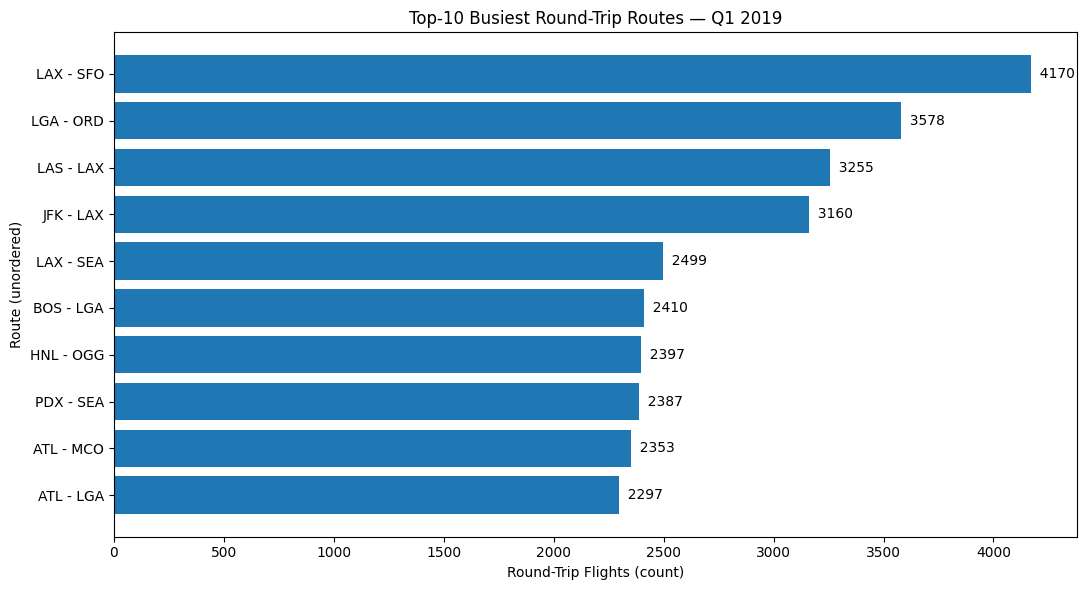

In [179]:
# Plot — Top-10 Busiest Round-Trip Routes (Q1 2019)
import matplotlib.pyplot as plt

plot_df = busiest.copy().sort_values("ROUND_TRIP_FLIGHTS", ascending=True)

plt.figure(figsize=(11,6))
plt.barh(plot_df["ROUTE_UND"], plot_df["ROUND_TRIP_FLIGHTS"])
for i, v in enumerate(plot_df["ROUND_TRIP_FLIGHTS"].values):
    plt.text(v, i, f"  {v}", va="center")
plt.title("Top-10 Busiest Round-Trip Routes — Q1 2019")
plt.xlabel("Round-Trip Flights (count)")
plt.ylabel("Route (unordered)")
plt.tight_layout()
plt.savefig("/content/top10_busiest_routes_q1_2019.png", dpi=200, bbox_inches="tight")
plt.show()

# **Question 2 : The 10 most profitable round trip routes**
 (without considering the upfront airplane cost) in the quarter. Along with the profit, show total revenue, total cost, summary values of other key components and total round trip flights in the quarter for the top 10 most profitable routes.

 Excluding canceled flights from these calculations.


### Assumptions and Calculations for Most Profitable Round-Trip Routes

To calculate and rank the **Top 10 most profitable round-trip routes**, several business and operational assumptions were applied consistently across all datasets.



#### Financial & Operational Assumptions

1. **Seat Capacity:**  
   Each aircraft is assumed to have **200 seats**.

2. **Occupancy Rate:**  
   Actual passengers on each flight leg are estimated as:  
   `PAX_EST = OCCUPANCY_RATE × 200`

3. **Fare Estimation:**  
   - Fares were merged from the **Tickets dataset** using the route key `ROUTE_UND` (A–B = B–A).  
   - When missing, fares were estimated by **distance bins** (shorter routes → cheaper fares).  
   - Round-trip fares were divided by **2** to get a **per-leg fare**.

4. **Baggage Revenue:**  
   - 50% of passengers check one bag.  
   - Each bag generates **$35** in additional revenue.

5. **Flight Costs:**  
   - **Fuel, maintenance, crew, oil:** $8 per mile  
   - **Depreciation, insurance, and other costs:** $1.18 per mile  
     → Combined: **$9.18 per mile**
   - **Delay costs:** Only delays beyond the first 15 minutes are charged at **$75 per minute**.  
   - **Landing fees:**  
     - $10,000 for large airports  
     - $5,000 for medium airports

6. **Revenue and Cost Formulas:**
   - **Ticket Revenue:** `PAX_EST × FARE_PER_LEG_EST`  
   - **Baggage Revenue:** `PAX_EST × 0.5 × $35`  
   - **Total Revenue:** sum of the two above  
   - **Distance Cost:** `DISTANCE × $9.18`  
   - **Delay Cost:** `(Delay beyond 15 min) × $75`  
   - **Landing Cost:** based on destination airport type  
   - **Total Cost:** sum of all cost components  
   - **Profit:** `Total Revenue − Total Cost`


#### Aggregation and Ranking

- Each route (`ROUTE_UND`) combines both directions (A–B and B–A).  
- Profit, revenue, and cost components are **summed** for all legs of the route.  
- Total flights are divided by 2 to estimate **round-trip flights**.  
- Routes are then **sorted by total profit (descending)** to find the **Top 10 most profitable round trips**.






In [180]:
# Top-10 most profitable with component breakdowns
route_profit = (
    df.groupby("ROUTE_UND", as_index=False)
      .agg(
          TOTAL_REVENUE     = ("REVENUE_TOTAL","sum"),
          TOTAL_COST        = ("COST_TOTAL","sum"),
          TOTAL_PROFIT      = ("PROFIT","sum"),
          REVENUE_TICKET_SUM= ("REVENUE_TICKET","sum"),
          REVENUE_BAGGAGE_SUM=("REVENUE_BAGGAGE","sum"),
          COST_DISTANCE_SUM = ("COST_DISTANCE","sum"),
          COST_DELAY_SUM    = ("COST_DELAY","sum"),
          COST_LANDING_SUM  = ("COST_LANDING","sum"),
          TOTAL_FLIGHTS     = ("ROUTE_UND","size")
      )
)

route_profit["ROUND_TRIP_FLIGHTS"] = (route_profit["TOTAL_FLIGHTS"] // 2).astype(int)

top_profitable = (
    route_profit.sort_values("TOTAL_PROFIT", ascending=False)
                .head(10)
                .reset_index(drop=True)
)

print("Top-10 Most Profitable Round-Trip Routes (Q1 2019):")
display(top_profitable[[
    "ROUTE_UND","TOTAL_PROFIT","TOTAL_REVENUE","TOTAL_COST",
    "REVENUE_TICKET_SUM","REVENUE_BAGGAGE_SUM",
    "COST_DISTANCE_SUM","COST_DELAY_SUM","COST_LANDING_SUM",
    "ROUND_TRIP_FLIGHTS"
]])


Top-10 Most Profitable Round-Trip Routes (Q1 2019):


,ROUTE_UND,TOTAL_PROFIT,TOTAL_REVENUE,TOTAL_COST,REVENUE_TICKET_SUM,REVENUE_BAGGAGE_SUM,COST_DISTANCE_SUM,COST_DELAY_SUM,COST_LANDING_SUM,ROUND_TRIP_FLIGHTS
0,DCA - ORD,"65,479,997.42","129,638,890.50","63,895,724.08","121,259,645.50","8,379,245.00","20,759,101.20","6,295,950.00","36,950,000.00",1847
1,ATL - CLT,"63,164,708.18","103,090,301.00","39,826,941.32","96,104,511.00","6,985,790.00","6,381,715.68","2,709,375.00","30,760,000.00",1538
2,DCA - LGA,"61,978,671.88","109,167,576.00","47,076,854.12","101,495,156.00","7,672,420.00","6,598,822.68","6,923,925.00","33,590,000.00",1679
3,CLT - FLO,"61,803,962.72","66,485,358.00","4,681,395.28","65,341,313.00","1,144,045.00","458,045.28","448,350.00","3,775,000.00",252
4,CLT - GSP,"61,505,945.50","79,588,080.00","18,082,134.50","76,070,930.00","3,517,150.00","1,065,109.50","1,547,025.00","15,470,000.00",773
5,CLT - GSO,"52,456,109.22","69,799,289.00","17,343,179.78","66,410,974.00","3,388,315.00","1,133,004.78","1,340,175.00","14,870,000.00",743
6,CLT - MYR,"51,697,379.96","64,691,321.00","12,993,941.04","61,627,456.00","3,063,865.00","1,951,466.04","887,475.00","10,155,000.00",677
7,CLT - ILM,"51,481,781.50","66,015,891.00","14,534,109.50","62,652,636.00","3,363,255.00","2,488,009.50","1,061,100.00","10,985,000.00",732
8,HNL - OGG,"50,224,828.00","91,434,887.50","41,198,574.00","80,568,262.50","10,866,625.00","4,400,892.00","858,600.00","35,945,000.00",2397
9,DFW - IAH,"50,003,753.72","90,217,778.00","40,181,194.28","83,485,108.00","6,732,670.00","6,076,425.60","4,566,825.00","29,550,000.00",1477


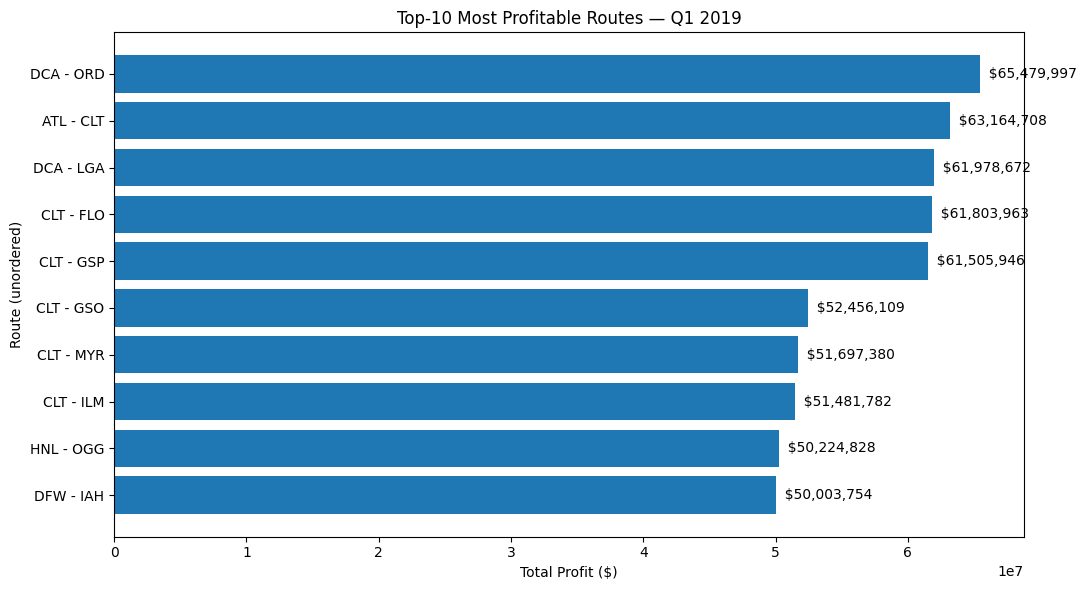

In [181]:
# Top-10 Most Profitable Routes (Total Profit $)
import matplotlib.pyplot as plt

plot_df = top_profitable.copy().sort_values("TOTAL_PROFIT", ascending=True)

plt.figure(figsize=(11,6))
plt.barh(plot_df["ROUTE_UND"], plot_df["TOTAL_PROFIT"])
for i, v in enumerate(plot_df["TOTAL_PROFIT"].values):
    plt.text(v, i, f"  ${v:,.0f}", va="center")
plt.title("Top-10 Most Profitable Routes — Q1 2019")
plt.xlabel("Total Profit ($)")
plt.ylabel("Route (unordered)")
plt.tight_layout()
plt.show()

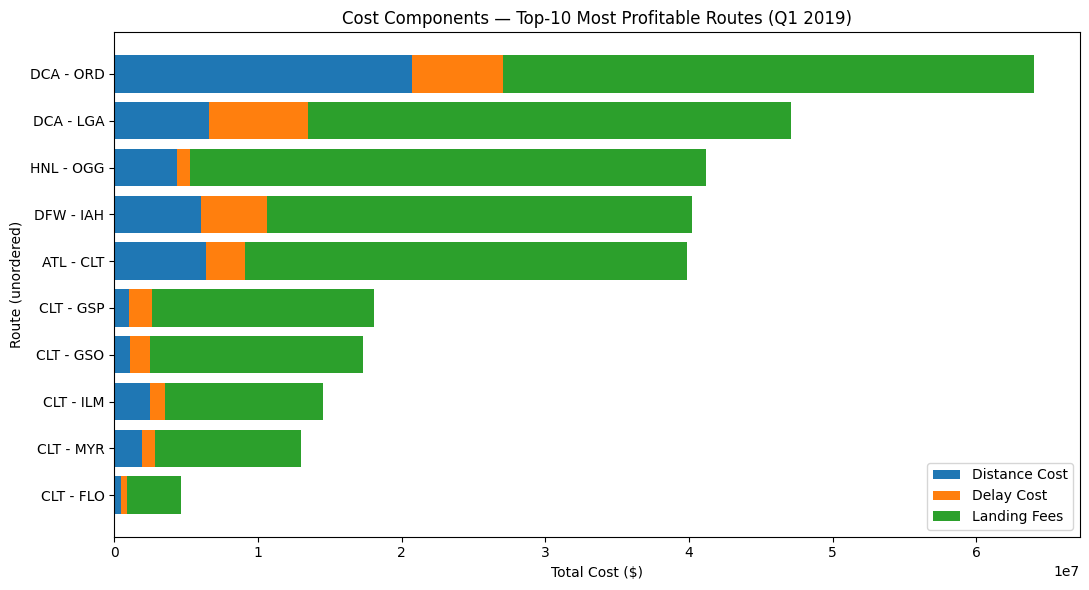

In [182]:
# Cost Component Breakdown for Top-10 Most Profitable Routes
import numpy as np
import matplotlib.pyplot as plt

plot_df = top_profitable.copy().sort_values("TOTAL_COST", ascending=True)
components = ["COST_DISTANCE_SUM", "COST_DELAY_SUM", "COST_LANDING_SUM"]
labels = ["Distance Cost", "Delay Cost", "Landing Fees"]

plt.figure(figsize=(11,6))
bottom = np.zeros(len(plot_df))
for comp, lab in zip(components, labels):
    plt.barh(plot_df["ROUTE_UND"], plot_df[comp].values, left=bottom, label=lab)
    bottom += plot_df[comp].values

plt.title("Cost Components — Top-10 Most Profitable Routes (Q1 2019)")
plt.xlabel("Total Cost ($)")
plt.ylabel("Route (unordered)")
plt.legend()
plt.tight_layout()
plt.show()


# **Question 3. The 5 round trip routes that you recommend to invest in based on any factors that you choose.**



In this step, we identify the **5 best round-trip routes** to invest in based on a balanced mix of financial and operational factors.  
Rather than relying only on total profit, we combine three key aspects that reflect both business performance and route stability.

**Key Factors Considered:**
1. **Profitability** – Measures how much each route earns after all operating costs.  
   - Based on total profit and profit margin.  
   - High profit routes are financially strong and sustainable.  

2. **Consistent Demand (Volume)** – Indicates how frequently the route is flown.  
   - Calculated using the total number of round-trip flights.  
   - Routes with more flights show higher passenger demand and market stability.  

3. **Reliability** – Reflects operational efficiency through delays.  
   - Based on average departure and arrival delays.  
   - Routes with fewer delays are more dependable and customer-friendly.  

**Scoring Approach:**
- Each route is scored using a weighted system:  
  - 50% **Profit** (financial strength)  
  - 30% **Volume** (demand consistency)  
  - 20% **Reliability** (on-time performance)  
- The combined **Investment Score** identifies routes that are both profitable and stable.  

This ensures we recommend routes that balance **high profitability**, **strong demand**, and **operational reliability** — making them ideal candidates for future investment.


In [183]:
# Route-level Profit and other metrics

route_profit = (
    df.groupby("ROUTE_UND", as_index=False)
      .agg(
          TOTAL_REVENUE       = ("REVENUE_TOTAL","sum"),
          TOTAL_COST          = ("COST_TOTAL","sum"),
          TOTAL_PROFIT        = ("PROFIT","sum"),
          REVENUE_TICKET_SUM  = ("REVENUE_TICKET","sum"),
          REVENUE_BAGGAGE_SUM = ("REVENUE_BAGGAGE","sum"),
          COST_DISTANCE_SUM   = ("COST_DISTANCE","sum"),
          COST_DELAY_SUM      = ("COST_DELAY","sum"),
          COST_LANDING_SUM    = ("COST_LANDING","sum"),
          TOTAL_FLIGHTS       = ("ROUTE_UND","size")
      )
)
route_profit.head()

,ROUTE_UND,TOTAL_REVENUE,TOTAL_COST,TOTAL_PROFIT,REVENUE_TICKET_SUM,REVENUE_BAGGAGE_SUM,COST_DISTANCE_SUM,COST_DELAY_SUM,COST_LANDING_SUM,TOTAL_FLIGHTS
0,ABE - ATL,"17,123,994.00","6,502,136.04","10,621,857.96","16,130,064.00","993,930.00","2,757,011.04","490,125.00","3,255,000.00",434
1,ABE - CLT,"17,041,524.50","6,375,371.16","10,666,153.34","15,879,979.50","1,161,545.00","2,216,621.16","393,750.00","3,765,000.00",502
2,ABE - DTW,"17,962,560.00","6,643,194.00","11,270,086.00","16,839,900.00","1,122,660.00","1,939,045.50","988,050.00","3,725,000.00",497
3,ABE - FLL,"537,462.00","719,905.20","-182,443.20","452,727.00","84,735.00","382,255.20","37,650.00","300,000.00",40
4,ABE - ORD,"12,026,409.00","5,619,057.96","6,338,450.04","11,299,424.00","726,985.00","1,921,190.40","1,324,875.00","2,395,000.00",320


Now  we need to calculate to how many round trips (not just one-way flights) were actually flown per route.
This helps measure **route activity or demand consistency**, a key business factor for deciding where to invest.

In [184]:
# Flight volume per route → true ROUND_TRIP_FLIGHTS (unique column name)
volume_df = (
    df.groupby("ROUTE_UND", as_index=False)
      .agg(TOTAL_FLIGHTS_VOL=("ROUTE_UND","size"))
)
volume_df["ROUND_TRIP_FLIGHTS"] = (volume_df["TOTAL_FLIGHTS_VOL"] // 2).astype(int)

Now we need to measure how reliable each route is by checking its average delays,
both for departures and arrivals, and combining them into one easy-to-compare score.

This helps identify routes that are not only profitable but also operate on time,
which is key for passenger satisfaction and airline efficiency.

In [185]:
# Reliability (lower delay = better)
delay_df = (
    df.groupby("ROUTE_UND", as_index=False)
      .agg(AVG_DEP_DELAY=("DEP_DELAY","mean"),
           AVG_ARR_DELAY=("ARR_DELAY","mean"))
)
delay_df["DELAY_MEAN"] = (delay_df["AVG_DEP_DELAY"].fillna(0) +
                          delay_df["AVG_ARR_DELAY"].fillna(0)) / 2.0

In [186]:
# Merge all route metrics together (avoid duplicate column names)
rec_df = (
    route_profit
      .merge(volume_df[["ROUTE_UND","ROUND_TRIP_FLIGHTS"]], on="ROUTE_UND", how="left")
      .merge(delay_df[["ROUTE_UND","AVG_DEP_DELAY","AVG_ARR_DELAY","DELAY_MEAN"]],
             on="ROUTE_UND", how="left")
)

In [187]:
#  Normalization helpers
def minmax(s: pd.Series):
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(np.full(len(s), 0.5), index=s.index)
    return (s - lo) / (hi - lo)




In [188]:
# Build scoring pillars
rec_df["MARGIN_PCT"]      = np.where(rec_df["TOTAL_REVENUE"] > 0,
                                     rec_df["TOTAL_PROFIT"]/rec_df["TOTAL_REVENUE"], 0.0)
rec_df["PROFIT_NORM"]     = minmax(rec_df["TOTAL_PROFIT"].fillna(0))
rec_df["VOLUME_NORM"]     = minmax(rec_df["ROUND_TRIP_FLIGHTS"].fillna(0))
rec_df["RELIABILITY_NORM"]= 1 - minmax(rec_df["DELAY_MEAN"].fillna(0))  # invert: lower delay → higher score

# Weighted composite investment score
W_PROFIT, W_VOLUME, W_RELIAB = 0.50, 0.30, 0.20
rec_df["INVEST_SCORE"] = (
    W_PROFIT  * rec_df["PROFIT_NORM"] +
    W_VOLUME  * rec_df["VOLUME_NORM"] +
    W_RELIAB  * rec_df["RELIABILITY_NORM"]
)

In [189]:
# Top-5 recommendations
top5_recommend = (
    rec_df.sort_values("INVEST_SCORE", ascending=False)
          .head(5)
          .reset_index(drop=True)
)
print("Top 5 Recommended Round-Trip Routes to Invest)")
display(top5_recommend[[
    "ROUTE_UND",
    "INVEST_SCORE",
    "TOTAL_PROFIT","TOTAL_REVENUE","TOTAL_COST","MARGIN_PCT",
    "ROUND_TRIP_FLIGHTS",
    "AVG_DEP_DELAY","AVG_ARR_DELAY"
]])


Top 5 Recommended Round-Trip Routes to Invest)


,ROUTE_UND,INVEST_SCORE,TOTAL_PROFIT,TOTAL_REVENUE,TOTAL_COST,MARGIN_PCT,ROUND_TRIP_FLIGHTS,AVG_DEP_DELAY,AVG_ARR_DELAY
0,DCA - ORD,0.81,"65,479,997.42","129,638,890.50","63,895,724.08",0.51,1847,10.19,6.33
1,ATL - CLT,0.78,"63,164,708.18","103,090,301.00","39,826,941.32",0.61,1538,5.77,-0.30
2,DCA - LGA,0.77,"61,978,671.88","109,167,576.00","47,076,854.12",0.57,1679,11.96,12.02
3,HNL - OGG,0.76,"50,224,828.00","91,434,887.50","41,198,574.00",0.55,2397,-0.34,-0.16
4,LAX - SFO,0.76,"31,734,003.22","162,924,377.00","131,053,418.78",0.19,4170,18.40,15.63


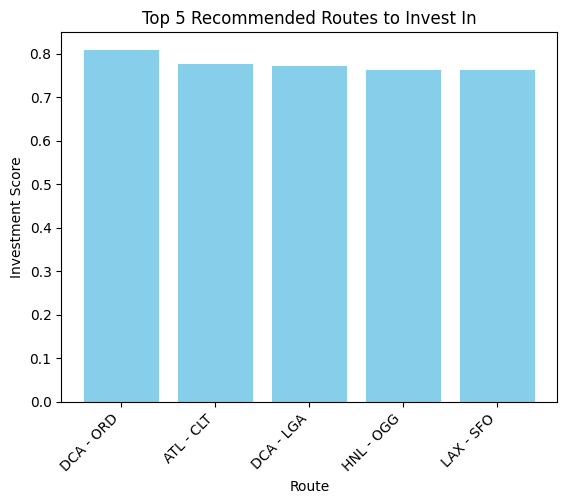

In [190]:
import matplotlib.pyplot as plt

# Simple bar chart for Investment Score
plt.bar(top5_recommend["ROUTE_UND"], top5_recommend["INVEST_SCORE"], color='skyblue')

plt.title("Top 5 Recommended Routes to Invest In")
plt.xlabel("Route")
plt.ylabel("Investment Score")
plt.xticks(rotation=45, ha="right")

plt.show()


| Factor                                        | Description                                                   | Why It Matters                                          | How It’s Used                                               |
| --------------------------------------------- | ------------------------------------------------------------- | ------------------------------------------------------- | ----------------------------------------------------------- |
| **Total Profit (TOTAL_PROFIT)**               | Net profit across all flights for the route (Revenue − Cost). | Measures direct financial success.                      | Used as a primary metric in the **profit score**.           |
| **Total Revenue (TOTAL_REVENUE)**             | Total money earned on that route.                             | Ensures large markets aren’t ignored.                   | Part of margin calculation.                                 |
| **Profit Margin (MARGIN_PCT)**                | Profit as a percentage of revenue.                            | Indicates cost efficiency and scalability.              | Used for context (not in the score).                        |
| **Round-Trip Flights (ROUND_TRIP_FLIGHTS)**   | Number of round trips flown.                                  | Reflects **demand consistency** and route popularity.   | Converted to a normalized “volume score.”                   |
| **Average Delays (DELAY_MEAN)**               | Mean of average departure and arrival delays.                 | Captures **reliability** and customer satisfaction.     | Inverted — lower delay = higher “reliability score.”        |
| **Composite Investment Score (INVEST_SCORE)** | Weighted score combining profit, volume, and reliability.     | Balances financial gain with stability and performance. | Computed as:<br>`0.5*Profit + 0.3*Volume + 0.2*Reliability` |


# **Question 4 : The number of round trip flights it will take to breakeven on the upfront airplane cost for each of the 5 round trip routes that you recommend. Print key summary components for these routes.**

To analyze how long it would take for each of the top 5 recommended routes to recover the $90 million aircraft investment.
We will,
- Calculate the average profit per round trip for each route.

- Determine how many round trips are required to break even on the aircraft’s cost.

- Add supporting metrics such as average revenue and average cost per round trip to better understand route efficiency.

In [191]:
# Constant: aircraft purchase cost
AIRCRAFT_COST = 90_000_000  # $90 million per aircraft

In [192]:
# Selecting recommended top 5 routes
breakeven_df = top5_recommend.copy()

In [193]:
# average profit per round trip
breakeven_df["AVG_PROFIT_PER_RT"] = (
    breakeven_df["TOTAL_PROFIT"] / breakeven_df["ROUND_TRIP_FLIGHTS"]
).replace([np.inf, -np.inf], np.nan)

In [194]:
# how many round trips needed to recover $90M cost
breakeven_df["ROUNDS_TO_BREAKEVEN"] = (
    AIRCRAFT_COST / breakeven_df["AVG_PROFIT_PER_RT"]
).round(0)


In [195]:
# additional ROI insights
breakeven_df["AVG_REVENUE_PER_RT"] = (
    breakeven_df["TOTAL_REVENUE"] / breakeven_df["ROUND_TRIP_FLIGHTS"]
).round(0)
breakeven_df["AVG_COST_PER_RT"] = (
    breakeven_df["TOTAL_COST"] / breakeven_df["ROUND_TRIP_FLIGHTS"]
).round(0)

In [196]:
# Key summary components
print("Breakeven Analysis for 5 Recommended Routes (Upfront $90M per Aircraft):")
display(
    breakeven_df[
        [
            "ROUTE_UND",
            "ROUND_TRIP_FLIGHTS",
            "AVG_PROFIT_PER_RT",
            "AVG_REVENUE_PER_RT",
            "AVG_COST_PER_RT",
            "ROUNDS_TO_BREAKEVEN",
        ]
    ].sort_values("ROUNDS_TO_BREAKEVEN")
)


Breakeven Analysis for 5 Recommended Routes (Upfront $90M per Aircraft):


,ROUTE_UND,ROUND_TRIP_FLIGHTS,AVG_PROFIT_PER_RT,AVG_REVENUE_PER_RT,AVG_COST_PER_RT,ROUNDS_TO_BREAKEVEN
1,ATL - CLT,1538,"41,069.38","67,029.00","25,895.00","2,191.00"
2,DCA - LGA,1679,"36,914.04","65,019.00","28,039.00","2,438.00"
0,DCA - ORD,1847,"35,452.08","70,189.00","34,594.00","2,539.00"
3,HNL - OGG,2397,"20,953.20","38,146.00","17,188.00","4,295.00"
4,LAX - SFO,4170,"7,610.07","39,071.00","31,428.00","11,826.00"


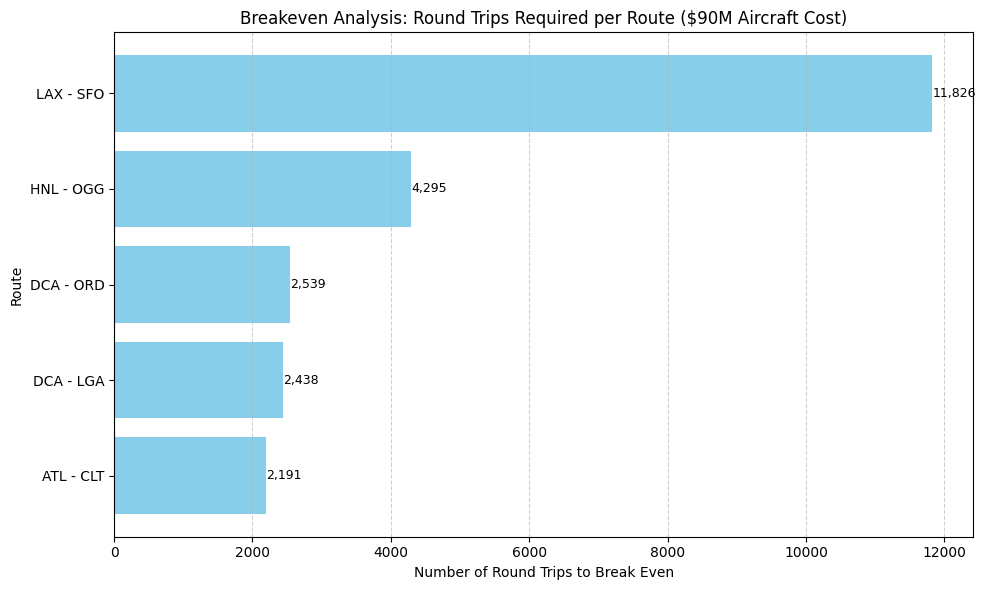

In [197]:
import matplotlib.pyplot as plt

# Sort routes by rounds to breakeven for better readability
breakeven_plot = breakeven_df.sort_values("ROUNDS_TO_BREAKEVEN", ascending=True)

# Create bar chart
plt.figure(figsize=(10, 6))
plt.barh(
    breakeven_plot["ROUTE_UND"],
    breakeven_plot["ROUNDS_TO_BREAKEVEN"],
    color='skyblue'
)

# Add labels and title
plt.xlabel("Number of Round Trips to Break Even")
plt.ylabel("Route")
plt.title("Breakeven Analysis: Round Trips Required per Route ($90M Aircraft Cost)")

# Annotate bars with values
for i, val in enumerate(breakeven_plot["ROUNDS_TO_BREAKEVEN"]):
    plt.text(val + 5, i, f"{int(val):,}", va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# **Question 5 : Key Performance Indicators (KPI’s) that you recommend tracking in the future to measure the success of the round trip routes that you recommend.**

### Key Performance Indicators (KPIs) for Future Monitoring

To evaluate and sustain the success of the **recommended round-trip routes**, airlines should continuously track the following KPIs. These indicators help balance profitability, reliability, customer satisfaction, and long-term growth.

#### **Essential KPIs (used in current analysis)**

1. **Distance** – Indicates operational scope and directly influences fuel cost, travel time, and ticket pricing.
2. **Fare** – Core driver of total revenue; tracking fare trends helps optimize pricing strategies.
3. **Arrival Delay** – Measures efficiency in reaching destinations on time and reflects route reliability.
4. **Departure Delay** – Impacts scheduling accuracy, fuel consumption, and downstream delays.
5. **Occupancy Rate (Load Factor)** – Reveals passenger demand and how efficiently seats are being utilized.


#### **Additional KPIs (recommended for continued monitoring)**

6. **Profit Margin per Route** – Shows cost-efficiency and overall financial health of each route.
7. **On-Time Performance (%)** – Tracks the percentage of flights arriving/departing within 15 minutes of schedule, a key service-quality metric.
8. **Airport Load Factor** – Measures traffic through airports to identify congestion that could cause future delays.
9. **Average Delay Cost per Minute** – Quantifies the financial effect of operational inefficiency and supports delay-reduction initiatives.
10. **Weather Impact Frequency** – Evaluates how often weather disrupts flight performance, useful for planning seasonal operations.
11. **Promotions & Pricing Effectiveness** – Tracks the revenue impact of fare sales and discounts to optimize marketing decisions.
12. **Flight Change Management Efficiency** – Measures how effectively route or schedule changes are communicated and handled, influencing customer experience.
13. **Breakeven Round Trips** – Tracks how many trips are needed to recover aircraft investment costs.
14. **Return on Investment (ROI)** – Assesses the long-term financial return from capital investment in specific routes.


#### **Future Strategic KPIs (for extended insight)**

15. **Seat Distribution by Class** – Understanding Business vs. Economy seat mix supports dynamic pricing and targeted upgrades.
16. **Target Audience Demographics** – Helps align service design and promotions with customer segments.
17. **Local Economic Factors** – Tracks regional income or tourism trends that may affect route profitability.
18. **Government or Policy Incentives** – Monitors regulations or subsidies that can influence route expansion and sustainability.
